Для начала посчитаем пустые значения (т.е. значения, которые равны -200) и заменим их на Nan.


Столбцы после удаления Unnamed: ['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']
Количество столбцов: 15

СРАВНЕНИЕ ДО И ПОСЛЕ УДАЛЕНИЯ ПУСТЫХ СТРОК
Строк ДО: 9471 → ПОСЛЕ: 9357 (удалено: 114)
Всего пропусков ДО: 18411 → ПОСЛЕ: 16701
Доля пропусков ДО: 12.96% → ПОСЛЕ: 11.90%


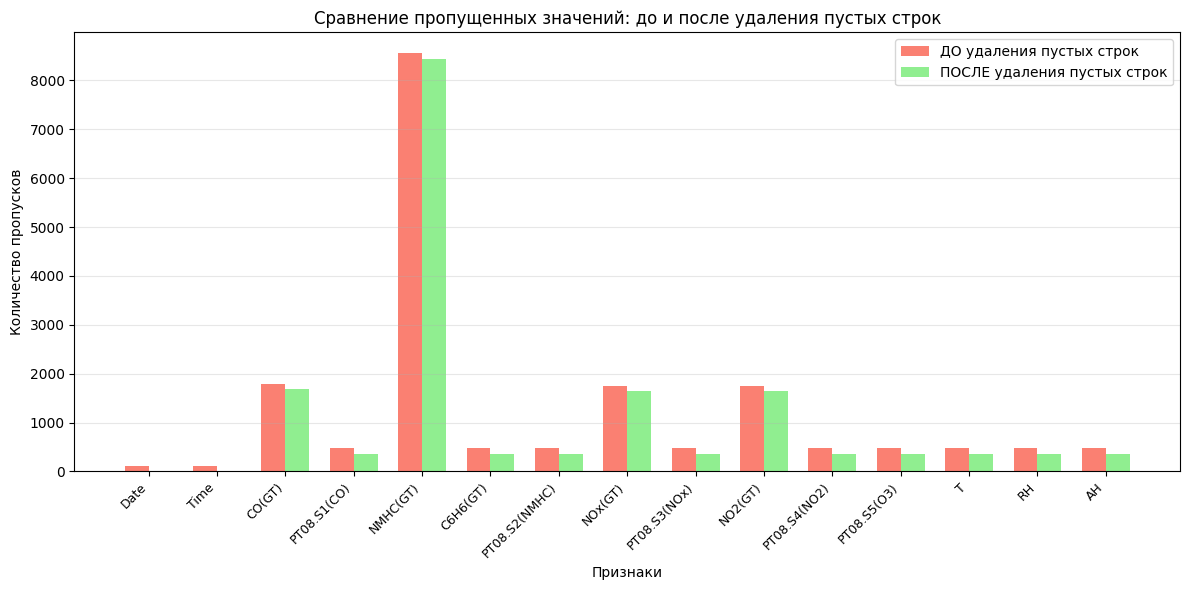


Было удалено 114 полностью пустых строк:
     Date Time  CO(GT)  PT08.S1(CO)  NMHC(GT)  C6H6(GT)  PT08.S2(NMHC)  \
9357  NaN  NaN     NaN          NaN       NaN       NaN            NaN   
9358  NaN  NaN     NaN          NaN       NaN       NaN            NaN   
9359  NaN  NaN     NaN          NaN       NaN       NaN            NaN   
9360  NaN  NaN     NaN          NaN       NaN       NaN            NaN   
9361  NaN  NaN     NaN          NaN       NaN       NaN            NaN   

      NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)   T  RH  AH  
9357      NaN           NaN      NaN           NaN          NaN NaN NaN NaN  
9358      NaN           NaN      NaN           NaN          NaN NaN NaN NaN  
9359      NaN           NaN      NaN           NaN          NaN NaN NaN NaN  
9360      NaN           NaN      NaN           NaN          NaN NaN NaN NaN  
9361      NaN           NaN      NaN           NaN          NaN NaN NaN NaN  
   ✅ Преобразование выполнено


/tmp/ipykernel_399/1868149604.py:87: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['datetime'] = pd.to_datetime(


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# ЗАГРУЗКА И ОЧИСТКА ОТ МУСОРНЫХ СТОЛБЦОВ
# ============================================================

df = pd.read_csv(
    'AirQuality.csv',
    sep=';',
    decimal=',',
    na_values=-200
)

# УДАЛЯЕМ ВСЕ Unnamed СТОЛБЦЫ СРАЗУ ПОСЛЕ ЗАГРУЗКИ
df = df.loc[:, ~df.columns.str.contains('Unnamed')]

print(f"Столбцы после удаления Unnamed: {df.columns.tolist()}")
print(f"Количество столбцов: {len(df.columns)}")
print("\n" + "=" * 60)

# ============================================================
# СРАВНЕНИЕ ПРОПУСКОВ ДО И ПОСЛЕ УДАЛЕНИЯ ПУСТЫХ СТРОК
# ============================================================

# Сохраняем статистику ДО
missing_before = df.isnull().sum()
total_missing_before = missing_before.sum()
total_cells_before = df.shape[0] * df.shape[1]
rows_before = df.shape[0]

# Удаляем пустые строки (где все NaN)
df_clean = df.dropna(how='all')

# Сохраняем статистику ПОСЛЕ
missing_after = df_clean.isnull().sum()
total_missing_after = missing_after.sum()
total_cells_after = df_clean.shape[0] * df_clean.shape[1]
rows_after = df_clean.shape[0]

# Вывод статистики
print("СРАВНЕНИЕ ДО И ПОСЛЕ УДАЛЕНИЯ ПУСТЫХ СТРОК")
print("=" * 60)
print(f"Строк ДО: {rows_before} → ПОСЛЕ: {rows_after} (удалено: {rows_before - rows_after})")
print(f"Всего пропусков ДО: {total_missing_before} → ПОСЛЕ: {total_missing_after}")
print(f"Доля пропусков ДО: {total_missing_before/total_cells_before*100:.2f}% → ПОСЛЕ: {total_missing_after/total_cells_after*100:.2f}%")

# ============================================================
# ГИСТОГРАММА СРАВНЕНИЯ (только для существующих столбцов)
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

# Берем ТЕКУЩИЕ столбцы (без Unnamed)
columns = df.columns.tolist()
x = np.arange(len(columns))
width = 0.35

# Используем df_clean для "после" и df для "до" (но с теми же столбцами)
missing_before_filtered = missing_before[columns]
missing_after_filtered = missing_after[columns]

ax.bar(x - width/2, missing_before_filtered, width, label='ДО удаления пустых строк', color='salmon')
ax.bar(x + width/2, missing_after_filtered, width, label='ПОСЛЕ удаления пустых строк', color='lightgreen')

ax.set_xticks(x)
ax.set_xticklabels(columns, rotation=45, ha='right', fontsize=9)
ax.set_xlabel('Признаки')
ax.set_ylabel('Количество пропусков')
ax.set_title('Сравнение пропущенных значений: до и после удаления пустых строк')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# ОТДЕЛЬНО: ПОСМОТРЕТЬ, КАКИЕ СТРОКИ БЫЛИ УДАЛЕНЫ
# ============================================================
removed_rows = df[df.isnull().all(axis=1)]
print(f"\nБыло удалено {len(removed_rows)} полностью пустых строк:")
print(removed_rows.head())

# Если есть столбцы Date и Time
if 'Date' in df_clean.columns and 'Time' in df_clean.columns:
  df_clean['datetime'] = pd.to_datetime(
        df_clean['Date'] + ' ' + df_clean['Time'],
        format='%d/%m/%Y %H.%M.%S',
        errors='coerce'
  )
  df_clean = df_clean.set_index('datetime')
  df_clean = df_clean.drop(['Date', 'Time'], axis=1)
  print("   ✅ Преобразование выполнено")
else:
  print("   ❌ Столбцы Date/Time не найдены. Индекс не может быть преобразован")

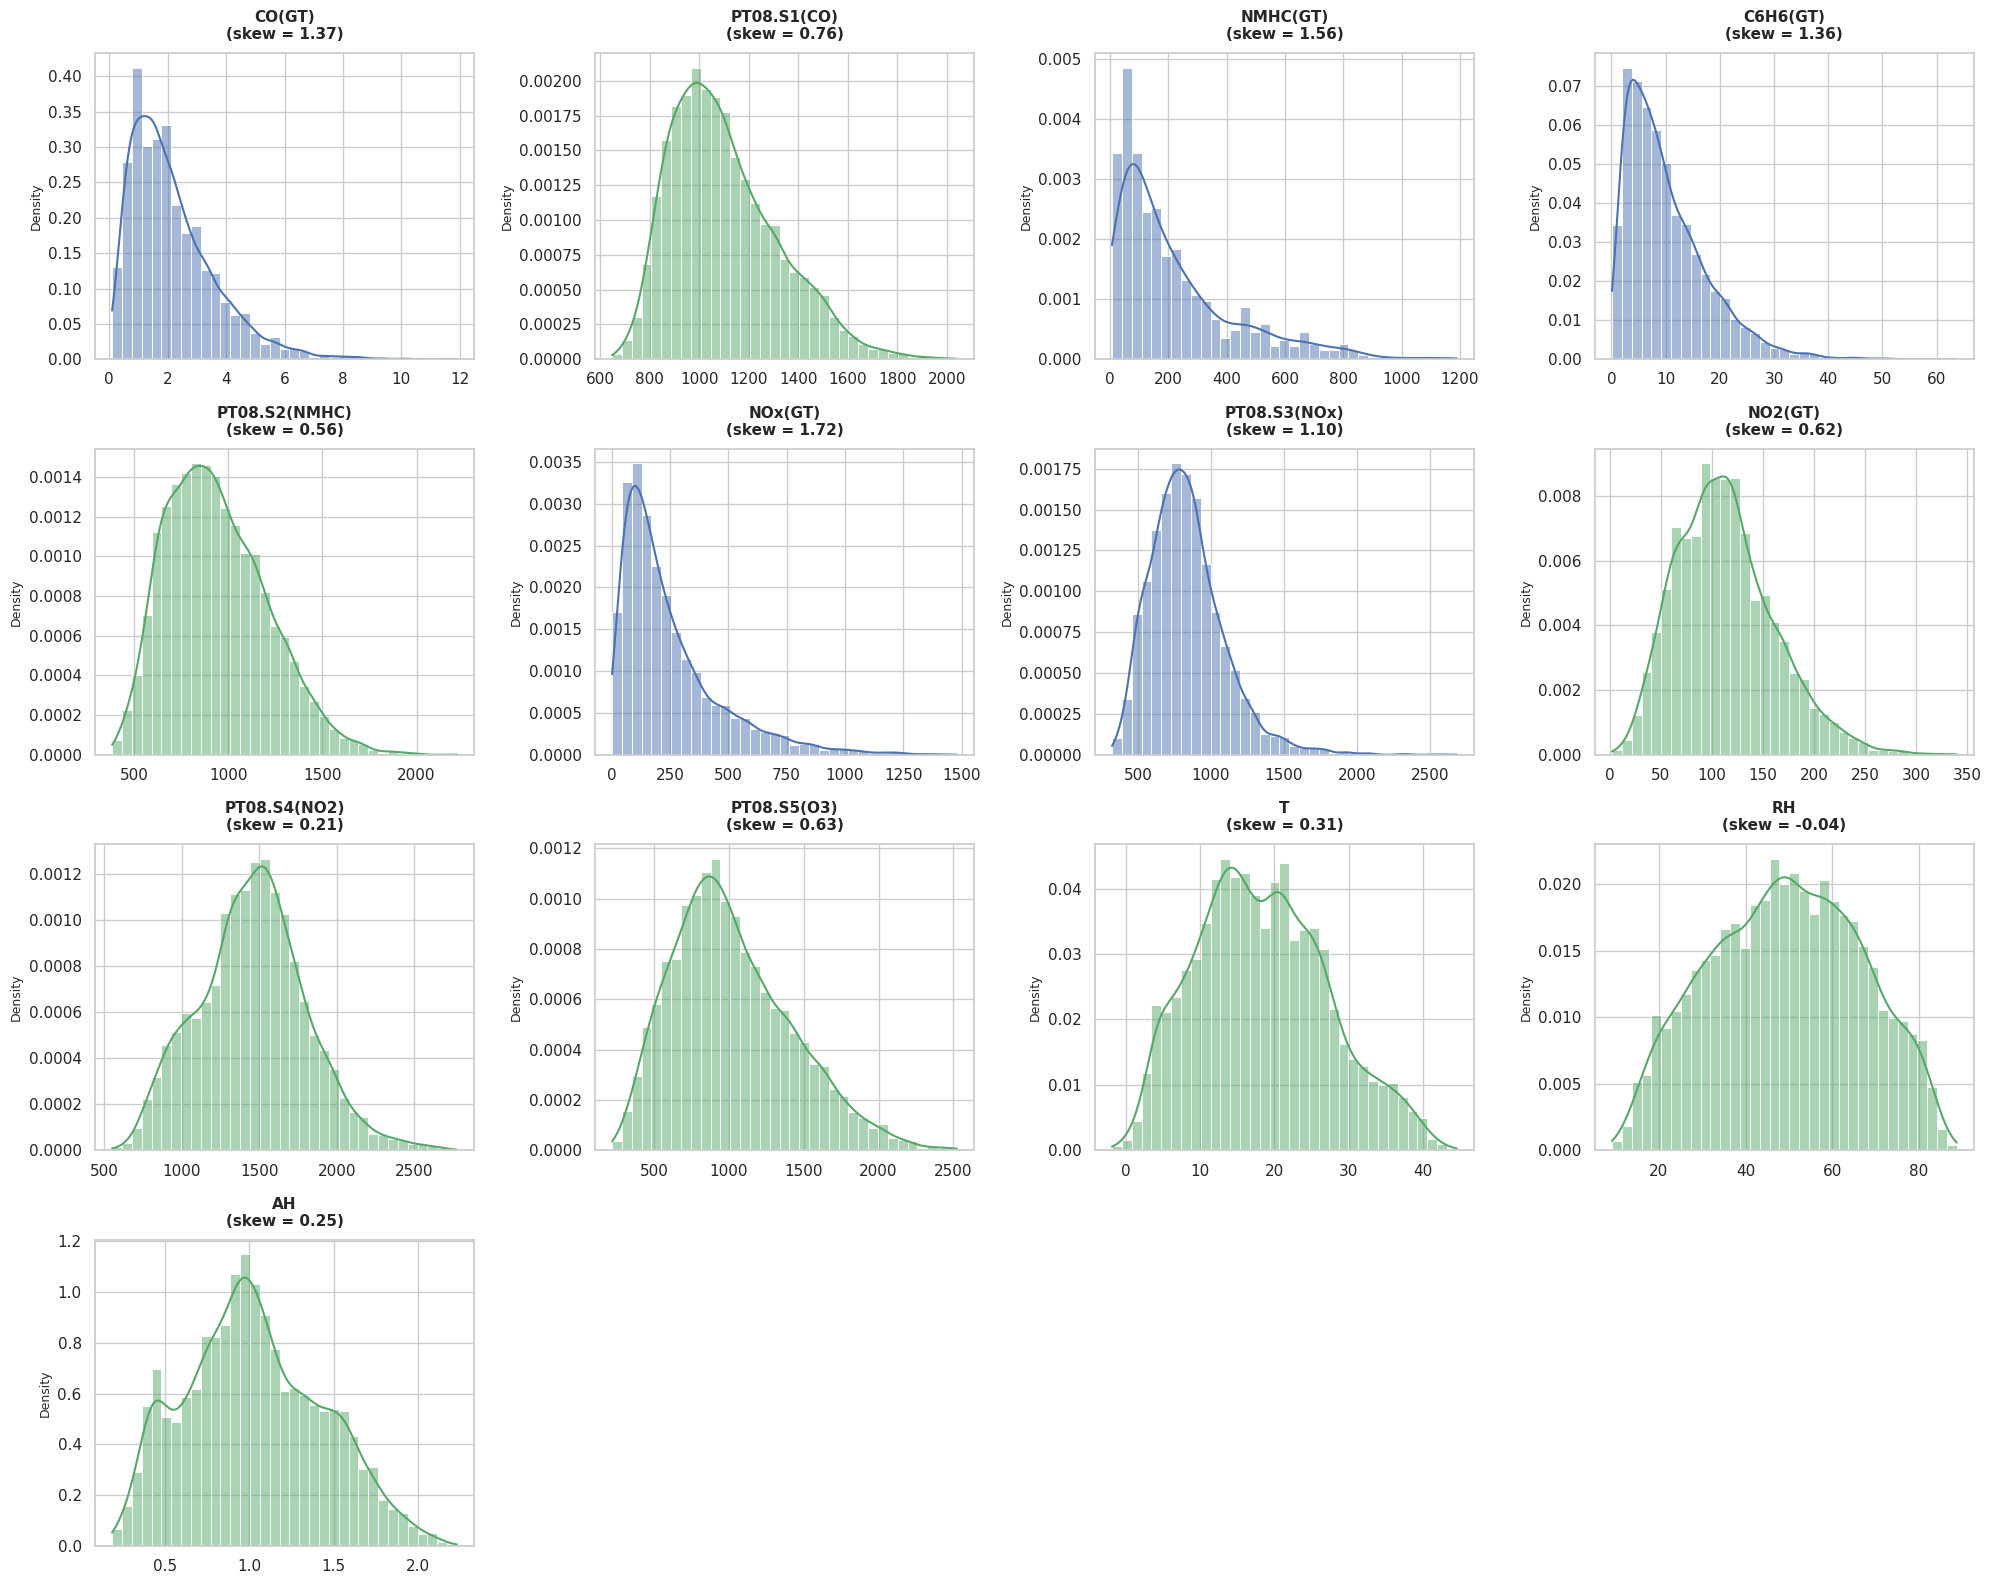

In [ ]:
import math
# 1. Настраиваем красивый стиль
sns.set_theme(style="whitegrid")

# 2. Отбираем только числовые колонки (исключаем Date, Time или Column1)
# Если у тебя индекс не настроен, код просто возьмет всё, где есть цифры
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Убираем технический столбец индекса, если он попал в выборку
if 'Column1' in numeric_cols:
    numeric_cols.remove('Column1')

# 3. Автоматически считаем, сколько нужно строк и столбцов в сетке
num_plots = len(numeric_cols)
num_cols = 4  # фиксируем 4 графика в ширину
num_rows = math.ceil(num_plots / num_cols)  # считаем строки вверх

# 4. Создаем общую фигуру для всей матрицы графиков
fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 4 * num_rows))
axes = axes.flatten()  # превращаем матрицу в одномерный массив для удобства в цикле

# 5. Цикл по всем каналам
for i, col in enumerate(numeric_cols):
    clean_data = df[col].dropna()

    # Считаем реальный skew для текущего столбца
    skew_val = clean_data.skew()

    # Автоматически определяем тип распределения по значению skew
    if skew_val > 1.0:
        dist_type = f"(skew = {skew_val:.2f})"
        color = "#4C72B0"  # классический синий для газов с выбросами
    elif skew_val < -1.0:
        dist_type = f"(skew = {skew_val:.2f})"
        color = "#C44E52"  # красный
    else:
        # Если skew около нуля, это либо мультимодальное (как T/RH), либо симметричный холм
        if col in ['T', 'RH']:
            dist_type = f"(skew = {skew_val:.2f})"
        else:
            dist_type = f"(skew = {skew_val:.2f})"
        color = "#55A868"  # зеленый для ровных метеопараметров

    # Строим гистограмму с линией плотности (KDE)
    sns.histplot(clean_data, kde=True, stat="density", color=color, ax=axes[i], bins=35)

    # Настраиваем заголовки и подписи
    axes[i].set_title(f"{col}\n{dist_type}", fontsize=11, fontweight='bold', pad=10)
    axes[i].set_xlabel("")  # убираем дублирующую подпись снизу, так как имя есть в заголовке
    axes[i].set_ylabel("Density", fontsize=9)

# 6. Если в сетке остались пустые лишние ячейки (например, колонок 13, а мест 16) — скрываем их
for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])

# Автоматически подгоняем размеры и отступы, чтобы тексты не налезали друг на друга
plt.tight_layout()

# 7. Выводим шедевр на экран
plt.show()

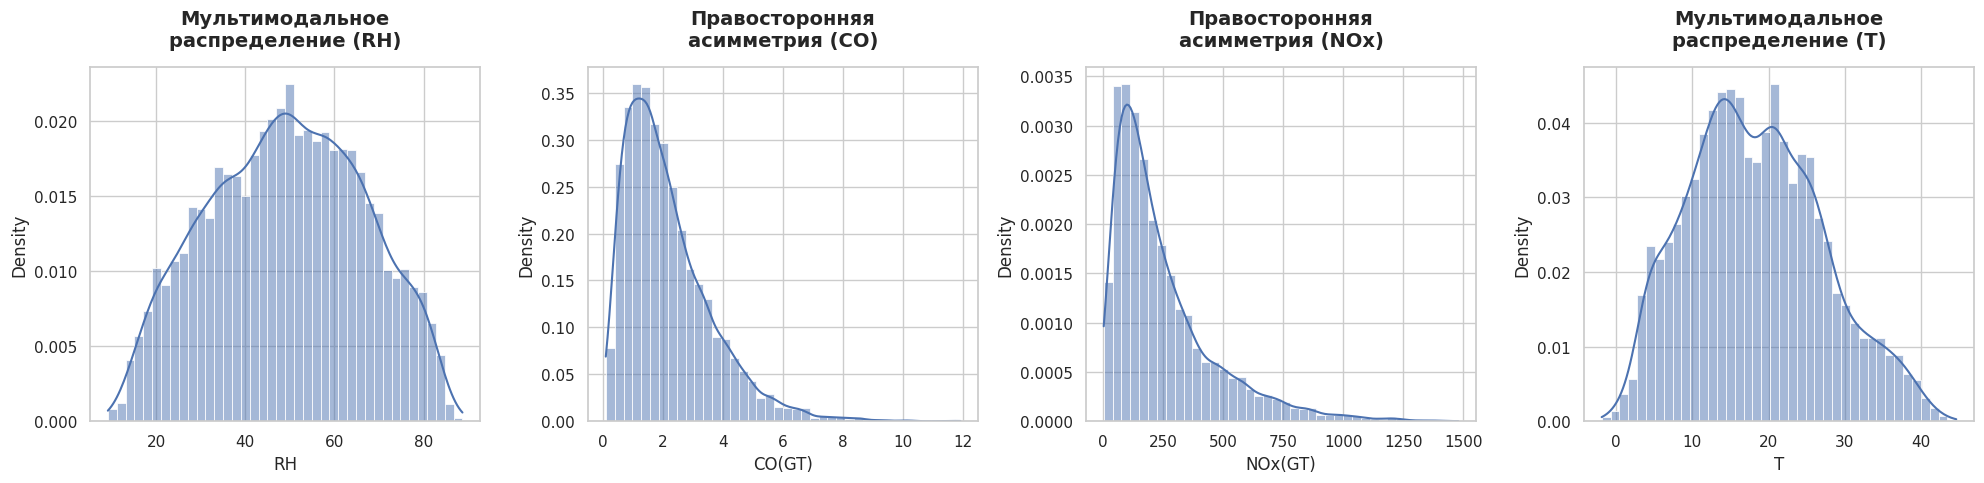

In [ ]:
# 1. Настраиваем красивый стиль графиков, как в seaborn
sns.set_theme(style="whitegrid")

# 2. Выбираем 4 ключевых столбца для демонстрации разных типов распределений
# T и RH покажут мультимодальность, а CO(GT) и NOx(GT) — правую асимметрию
columns_to_plot = ['RH', 'CO(GT)', 'NOx(GT)', 'T']
titles = [
    "Мультимодальное\nраспределение (RH)",
    "Правосторонняя\nасимметрия (CO)",
    "Правосторонняя\nасимметрия (NOx)",
    "Мультимодальное\nраспределение (T)"
]

# 3. Создаем сетку: 1 строка, 4 графика
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, col in enumerate(columns_to_plot):
    # Удаляем NaN перед построением, чтобы matplotlib не ругался
    clean_data = df[col].dropna()

    # Строим гистограмму (hist=True) со сглаженной линией (kde=True)
    sns.histplot(clean_data, kde=True, stat="density", color="b", ax=axes[i], bins=40)

    # Добавляем подписи и заголовки
    axes[i].set_title(titles[i], fontsize=14, fontweight='bold', pad=15)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel("Density", fontsize=12)

# Автоматически выравниваем отступы между графиками
plt.tight_layout()

# 4. Показываем результат
plt.show()

затем выполним этап 1. просмотрим, что у нас там есть.


In [ ]:
# ======================
# ЭТАП 1. ЗАГРУЗКА И ПЕРВИЧНОЕ ЗНАКОМСТВО С ДАННЫМИ
# ======================

print("=" * 70)
print("ЭТАП 1: ПЕРВИЧНЫЙ АНАЛИЗ ДАННЫХ")
print("=" * 70)

# 0. ПРОВЕРКА И ПРЕОБРАЗОВАНИЕ ИНДЕКСА (если еще не datetime)
if not isinstance(df.index, pd.DatetimeIndex):
    print("\n⚠️ Индекс НЕ является datetime. Выполняю преобразование...")

    # Если есть столбцы Date и Time
    if 'Date' in df.columns and 'Time' in df.columns:
        df['datetime'] = pd.to_datetime(
            df['Date'] + ' ' + df['Time'],
            format='%d/%m/%Y %H.%M.%S',
            errors='coerce'
        )
        df = df.set_index('datetime')
        df = df.drop(['Date', 'Time'], axis=1)
        print("   ✅ Преобразование выполнено")
    else:
        print("   ❌ Столбцы Date/Time не найдены. Индекс не может быть преобразован")

# 1. Размерность
rows, cols = df.shape
print(f"\n▶ Размерность данных:")
print(f"   - Количество строк (наблюдений): {rows}")
print(f"   - Количество столбцов (признаков): {cols}")

# 2. Первые строки данных
print(f"\n▶ Первые 5 строк данных:")
print(df.head())

# 3. Типы данных
print(f"\n▶ Типы данных каждого столбца:")
print(df.dtypes)

# 4. Информация о данных
print(f"\n▶ Полная информация о данных (info):")
df.info()

# 5. Проверка индекса
print(f"\n▶ Анализ временного индекса:")
print(f"   Тип индекса: {type(df.index)}")

if isinstance(df.index, pd.DatetimeIndex):
    print(f"   Начало временного ряда: {df.index.min()}")
    print(f"   Конец временного ряда: {df.index.max()}")
    print(f"   Длительность ряда: {df.index.max() - df.index.min()}")
    print(f"   Количество уникальных временных меток: {df.index.nunique()}")
    print(f"   Есть ли дубликаты времени: {'ДА' if df.index.duplicated().any() else 'НЕТ'}")

    # 6. Определение частоты дискретизации (только если индекс datetime)
    time_diffs = df.index.to_series().diff().dropna()
    if len(time_diffs) > 0:
        avg_seconds = time_diffs.dt.total_seconds().mean()
        print(f"\n▶ Частота дискретизации:")
        print(f"   Средний интервал: {avg_seconds:.0f} секунд ({avg_seconds/3600:.1f} часов)")

        inferred_freq = pd.infer_freq(df.index)
        if inferred_freq:
            print(f"   Определенная частота: {inferred_freq}")
        else:
            print(f"   Частота не определена (есть пропуски или нерегулярный интервал)")
else:
    print("   ⚠️ Индекс НЕ является DatetimeIndex. Частота дискретизации не определена.")
    print(f"   Текущий тип индекса: {type(df.index)}")

# 7. Многомерность ряда
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
print(f"\n▶ Количество числовых каналов (измерений): {len(numeric_cols)}")
print(f"   Список каналов: {numeric_cols[:5]}..." if len(numeric_cols) > 5 else f"   Список каналов: {numeric_cols}")
print(f"   Ряд является многомерным: {'ДА' if len(numeric_cols) > 1 else 'НЕТ'}")

# 8. Итоговая статистика
print("\n" + "=" * 70)
print("ИТОГОВАЯ СТАТИСТИКА ПО ЭТАПУ 1")
print("=" * 70)

total_elements = rows * cols
print(f"✅ Общее количество элементов: {total_elements:,}")
print(f"✅ Количество строк: {rows:,}")
print(f"✅ Количество столбцов: {cols}")
print(f"✅ Количество числовых каналов: {len(numeric_cols)}")

if isinstance(df.index, pd.DatetimeIndex):
    print(f"✅ Временной интервал: с {df.index.min()} по {df.index.max()}")
else:
    print(f"⚠️ Временной интервал не определен (индекс не datetime)")

print("\n" + "=" * 70)

ЭТАП 1: ПЕРВИЧНЫЙ АНАЛИЗ ДАННЫХ

⚠️ Индекс НЕ является datetime. Выполняю преобразование...
   ✅ Преобразование выполнено

▶ Размерность данных:
   - Количество строк (наблюдений): 9471
   - Количество столбцов (признаков): 13

▶ Первые 5 строк данных:
                     CO(GT)  PT08.S1(CO)  NMHC(GT)  C6H6(GT)  PT08.S2(NMHC)  \
datetime                                                                      
2004-03-10 18:00:00     2.6       1360.0     150.0      11.9         1046.0   
2004-03-10 19:00:00     2.0       1292.0     112.0       9.4          955.0   
2004-03-10 20:00:00     2.2       1402.0      88.0       9.0          939.0   
2004-03-10 21:00:00     2.2       1376.0      80.0       9.2          948.0   
2004-03-10 22:00:00     1.6       1272.0      51.0       6.5          836.0   

                     NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  \
datetime                                                            
2004-03-10 18:00:00    166.0        1056.0    113.0    

И выполним этап 2. Выполним визуализацию.

Всего каналов для визуализации: 13
Список каналов: ['CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']
Длина ряда: 9326 строк
Соответствие каналов и цветов:
  CO(GT) → red
  PT08.S1(CO) → blue
  NMHC(GT) → darkviolet
  C6H6(GT) → black
  PT08.S2(NMHC) → red
  NOx(GT) → blue
  PT08.S3(NOx) → darkviolet
  NO2(GT) → black
  PT08.S4(NO2) → red
  PT08.S5(O3) → blue
  T → darkviolet
  RH → black
  AH → red


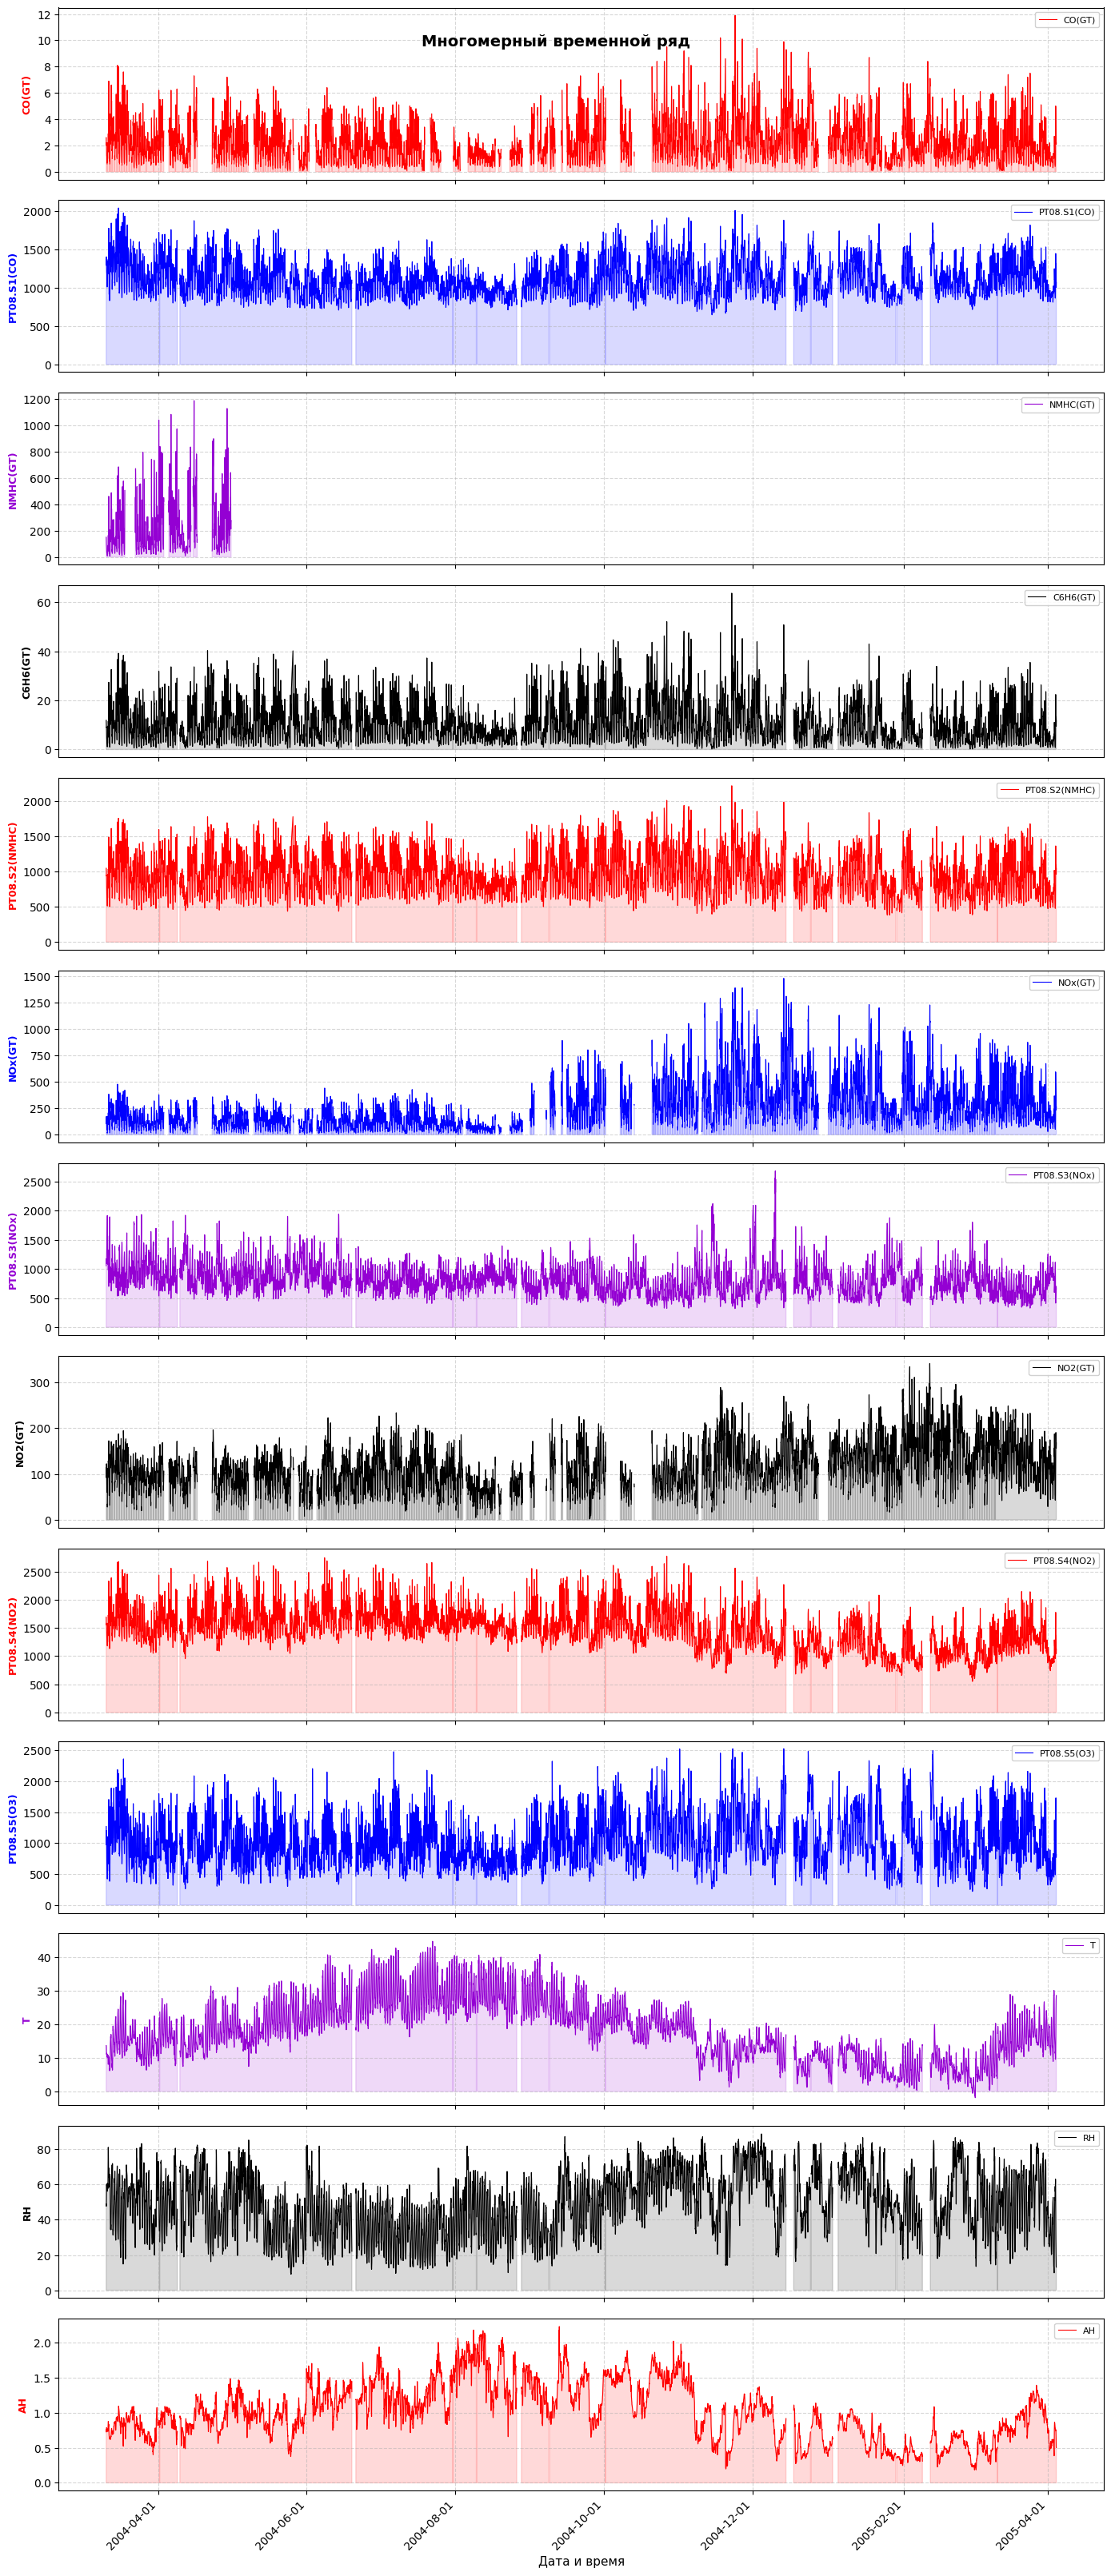

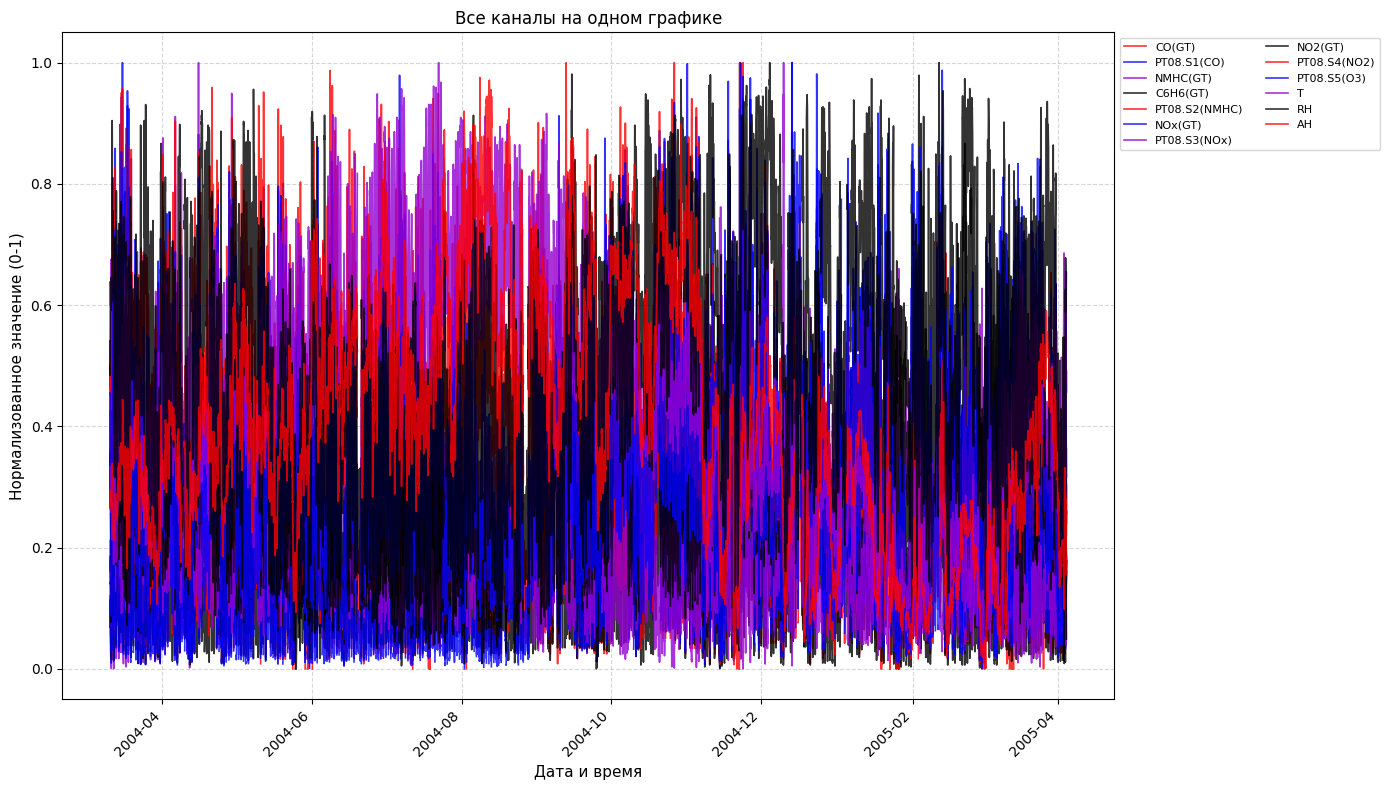

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ============================================================
# ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ
# ============================================================

df = pd.read_csv(
    'AirQuality.csv',
    sep=';',
    decimal=',',
    na_values=-200
)

# Удаляем Unnamed столбцы
df = df.loc[:, ~df.columns.str.contains('Unnamed')]

# Создаем datetime индекс
df['datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    format='%d/%m/%Y %H.%M.%S'
)
df = df.set_index('datetime').drop(['Date', 'Time'], axis=1)

# Удаляем полностью пустые строки
df = df.dropna(how='all')

# Выбираем только числовые каналы
numeric_cols = df.select_dtypes(include=['float64', 'float32']).columns.tolist()

print(f"Всего каналов для визуализации: {len(numeric_cols)}")
print(f"Список каналов: {numeric_cols}")
print(f"Длина ряда: {len(df)} строк")
print("=" * 60)

# ============================================================
# ЗАДАННАЯ ПАЛИТРА ЦВЕТОВ (красный, синий, темно-фиолетовый, черный)
# ============================================================
custom_colors = ['red', 'blue', 'darkviolet', 'black']

# Если каналов больше 4, повторяем цвета (циклически)
colors = [custom_colors[i % len(custom_colors)] for i in range(len(numeric_cols))]

print("Соответствие каналов и цветов:")
for col, color in zip(numeric_cols, colors):
    print(f"  {col} → {color}")

# ============================================================
# ВИЗУАЛИЗАЦИЯ: каждый канал отдельно (строго заданные цвета)
# ============================================================

n_channels = len(numeric_cols)
fig_height = max(10, n_channels * 2.5)
fig, axes = plt.subplots(n_channels, 1, figsize=(14, fig_height), sharex=True)

if n_channels == 1:
    axes = [axes]

fig.suptitle('Многомерный временной ряд',
             fontsize=14, fontweight='bold')

for i, (col, color) in enumerate(zip(numeric_cols, colors)):
    ax = axes[i]

    # Линейный график заданным цветом
    ax.plot(df.index, df[col], linewidth=0.8, color=color, label=col)

    # Заливка области (полупрозрачная, того же цвета)
    ax.fill_between(df.index, df[col], alpha=0.15, color=color)

    ax.set_ylabel(col, fontsize=9, fontweight='bold', color=color)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper right', fontsize=8, framealpha=0.9)

    if i < n_channels - 1:
        ax.set_xticklabels([])
        ax.xaxis.set_tick_params(labelbottom=False)

axes[-1].set_xlabel('Дата и время', fontsize=11)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.subplots_adjust(top=0.99, hspace=0.12)
plt.show()

# ============================================================
# ВСЕ КАНАЛЫ НА ОДНОМ ГРАФИКЕ (те же цвета)
# ============================================================

fig, ax = plt.subplots(figsize=(14, 8))

for i, col in enumerate(numeric_cols):
    # Нормализация min-max для визуального сравнения формы
    normalized = (df[col] - df[col].min()) / (df[col].max() - df[col].min())
    ax.plot(df.index, normalized, linewidth=1.2, color=colors[i], label=col, alpha=0.8)

ax.set_ylabel('Нормализованное значение (0-1)', fontsize=11)
ax.set_xlabel('Дата и время', fontsize=11)
ax.set_title('Все каналы на одном графике', fontsize=12)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=8, ncol=2)
ax.grid(True, linestyle='--', alpha=0.5)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [ ]:
df_analyze = pd.DataFrame(index=numeric_cols)

# Основные статистики
df_analyze['count'] = df[numeric_cols].count()          # количество НЕпустых значений
df_analyze['mean'] = df[numeric_cols].mean()            # среднее арифметическое
df_analyze['std'] = df[numeric_cols].std()              # стандартное отклонение
df_analyze['min'] = df[numeric_cols].min()              # минимум
df_analyze['Q1'] = df[numeric_cols].quantile(0.25)      # 1-й квартиль (25%)
df_analyze['median'] = df[numeric_cols].median()        # медиана (50%)
df_analyze['Q3'] = df[numeric_cols].quantile(0.75)      # 3-й квартиль (75%)
df_analyze['max'] = df[numeric_cols].max()              # максимум
df_analyze['skew'] = df[numeric_cols].skew()            # коэффициент асимметрии
df_analyze['missing_count'] = df[numeric_cols].isnull().sum()   # количество пропусков
df_analyze['missing_percent'] = (df_analyze['missing_count'] / len(df)) * 100

# Округляем до 3 знаков
df_analyze = df_analyze.round(3)

# ============================================================
# ВЫВОД ТАБЛИЦЫ
# ============================================================

print("=" * 100)
print("СВОДНАЯ ТАБЛИЦА СТАТИСТИЧЕСКИХ ХАРАКТЕРИСТИК (df_analyze)")
print("=" * 100)
print(df_analyze.to_string())

# ============================================================
# СОХРАНЕНИЕ В CSV (если нужно)
# ============================================================

df_analyze.to_csv('statistics_analysis.csv', encoding='utf-8-sig')
print("\n✅ Таблица сохранена в файл 'statistics_analysis.csv'")


СВОДНАЯ ТАБЛИЦА СТАТИСТИЧЕСКИХ ХАРАКТЕРИСТИК (df_analyze)
               count      mean      std      min        Q1    median        Q3       max   skew  missing_count  missing_percent
CO(GT)          7674     2.153    1.453    0.100     1.100     1.800     2.900    11.900  1.370           1652           17.714
PT08.S1(CO)     8991  1099.833  217.080  647.000   937.000  1063.000  1231.000  2040.000  0.756            335            3.592
NMHC(GT)         914   218.812  204.460    7.000    67.000   150.000   297.000  1189.000  1.557           8412           90.199
C6H6(GT)        8991    10.083    7.450    0.100     4.400     8.200    14.000    63.700  1.362            335            3.592
PT08.S2(NMHC)   8991   939.153  266.831  383.000   734.500   909.000  1116.000  2214.000  0.562            335            3.592
NOx(GT)         7718   246.897  212.979    2.000    98.000   180.000   326.000  1479.000  1.716           1608           17.242
PT08.S3(NOx)    8991   835.494  256.817  322.0

In [ ]:
# ======================================================================
# АВТОМАТИЧЕСКИЙ АНАЛИЗ И ОТВЕТЫ НА ВОПРОСЫ ЭТАПА 3
# ======================================================================

print("\n" + "=" * 80)
print("АНАЛИЗ РАСПРЕДЕЛЕНИЙ И СТРУКТУРЫ ВРЕМЕННЫХ РЯДОВ")
print("=" * 80)

# --- 1. Значения за допустимыми пределами ---
print("\n▶ 1. ЗНАЧЕНИЯ ЗА ДОПУСТИМЫМИ ПРЕДЕЛАМИ:")

# Выделяем только химические датчики (исключаем метеоданные)
chemical_cols = [c for c in df_analyze.index if c not in ['T', 'RH', 'AH']]

# Фильтруем строки через стандартный синтаксис pandas (избегаем ошибок numexpr)
invalid_chem = df_analyze.loc[chemical_cols]
invalid_chem = invalid_chem[invalid_chem['min'] < 0]

if not invalid_chem.empty:
    print("  ⚠️ Обнаружены физически невозможные (отрицательные) концентрации:")
    for col in invalid_chem.index:
        # Считаем точное количество отрицательных элементов в исходном df
        neg_cnt = (df[col] < 0).sum()
        print(f"     - {col:<12} : {neg_cnt} записей со значениями < 0")
else:
    print("  ✅ Все концентрации газов находятся в допустимых пределах (min >= 0)")

# Отдельно выводим минимальную температуру, если она есть в расчетах
if 'T' in df_analyze.index:
    print(f"  ℹ️ Метеоданные: минимальная температура T = {df_analyze.loc['T', 'min']:.1f}°C (физически допустимо)")


# --- 2. Симметричность распределения ---
print("\n▶ 2. СИММЕТРИЧНОСТЬ РАСПРЕДЕЛЕНИЯ (Среднее vs Медиана):")

# Считаем процентное отклонение среднего от медианы
diff_pct = (abs(df_analyze['mean'] - df_analyze['median']) / df_analyze['median']) * 100

# Критерий сильной асимметрии: отклонение > 15% ИЛИ коэффициент skew > 1.0
asym_mask = (diff_pct > 15.0) | (df_analyze['skew'].abs() > 1.0)
asymmetric_channels = df_analyze[asym_mask].index.tolist()

if asymmetric_channels:
    print("  ⚠️ Выявлена сильная правосторонняя асимметрия (высокий skew, длинный хвост пиков):")
    for col in asymmetric_channels:
        print(f"     - {col:<12} | Ср: {df_analyze.loc[col, 'mean']:.2f} vs Мед: {df_analyze.loc[col, 'median']:.2f} "
              f"(Разница: {diff_pct[col]:.1f}%, Skew: {df_analyze.loc[col, 'skew']:.3f})")
    print(f"  💡 Вывод: Для каналов {asymmetric_channels} в будущем необходимы нелинейные преобразования (log1p или Бокс-Кокс).")
else:
    print("  ✅ Распределения всех каналов симметричны. Нелинейные преобразования не требуются.")


# --- 3. Дискретность ряда и равномерность интервалов ---
print("\n▶ 3. ДИСКРЕТНОСТЬ РЯДА И РАВНОМЕРНОСТЬ ИНТЕРВАЛОВ:")

if isinstance(df.index, pd.DatetimeIndex):
    freq = pd.infer_freq(df.index)
    time_diffs = df.index.to_series().diff().dropna()
    unique_diffs = time_diffs.unique()

    print("  ℹ️ Базовая дискретность ряда: 1 час (часовой шаг сбора данных).")
    if freq and len(unique_diffs) == 1:
        print(f"  ✅ Временные интервалы строго равномерны. Шаг: {freq}")
    else:
        most_common = time_diffs.value_counts().idxmax()
        print("  ⚠️ Интервалы НЕРАВНОМЕРНЫЕ. В хронологии присутствуют разрывы (пропущенные часы в часовой сетке).")
        print(f"     - Самый частый шаг между записями: {most_common}")
        print(f"     - Количество различных временных интервалов в индексе: {len(unique_diffs)}")
else:
    print("  ❌ Предупреждение: Индекс исходного датафрейма `df` не является DatetimeIndex. Невозможно рассчитать шаги.")

print("  ℹ️ Дискретность одинакова для всех каналов (данные представляют собой единую синхронную матрицу).")


# --- 4. Разброс значений по каналам (std) ---
print("\n▶ 4. РАЗБРОС ЗНАЧЕНИЙ И МАСШТАБ ПРИЗНАКОВ:")
sorted_std = df_analyze['std'].sort_values(ascending=False)

print("  Каналы в порядке убывания стандартного отклонения (σ):")
for col, val in sorted_std.items():
    rating = "очень высокий" if val > 100 else ("средний" if val > 10 else "низкий")
    print(f"     - {col:<12} : σ = {val:.3f} ({rating} разброс)")

ratio = sorted_std.max() / sorted_std.min()
print(f"\n  → Максимальный разброс отличается от минимального в {ratio:.1f} раз.")

if ratio > 5.0:
    print(f"  ⚠️ Разброс между масштабами каналов отличается критически (более чем в 5 раз).")
    print("  💡 Вывод: МАСШТАБИРОВАНИЕ ДАННЫХ (StandardScaler или MinMaxScaler) ОБЯЗАТЕЛЬНО перед подачей в модели.")
else:
    print("  ✅ Масштабы признаков близки, жесткое масштабирование не требуется.")


# --- 5. Низкоинформативные каналы (std ≈ 0) ---
print("\n▶ 5. КАНАЛЫ С НУЛЕВЫМ РАЗБРОСОМ (std ≈ 0):")
near_zero = df_analyze[df_analyze['std'] < 0.01].index.tolist()

if near_zero:
    print(f"  ⚠️ Найдены неинформативные каналы-константы: {near_zero}")
    print("  💡 Вывод: Данные каналы рекомендуется удалить из анализа.")
else:
    print("  ✅ Каналов с околонулевым разбросом не обнаружено. Все каналы изменчивы и информативны.")

# Дополнительная проверка на катастрофический объём пропусков
if 'NMHC(GT)' in df_analyze.index and df_analyze.loc['NMHC(GT)', 'missing_percent'] > 80:
    print(f"  ⚠️ Критическое замечание: Канал NMHC(GT) содержит {df_analyze.loc['NMHC(GT)', 'missing_percent']:.1f}% пропусков.")
    print("     Его необходимо полностью исключить из дальнейшего анализа, несмотря на значимый разброс.")

print("=" * 80)


АНАЛИЗ РАСПРЕДЕЛЕНИЙ И СТРУКТУРЫ ВРЕМЕННЫХ РЯДОВ

▶ 1. ЗНАЧЕНИЯ ЗА ДОПУСТИМЫМИ ПРЕДЕЛАМИ:
  ✅ Все концентрации газов находятся в допустимых пределах (min >= 0)
  ℹ️ Метеоданные: минимальная температура T = -1.9°C (физически допустимо)

▶ 2. СИММЕТРИЧНОСТЬ РАСПРЕДЕЛЕНИЯ (Среднее vs Медиана):
  ⚠️ Выявлена сильная правосторонняя асимметрия (высокий skew, длинный хвост пиков):
     - CO(GT)       | Ср: 2.15 vs Мед: 1.80 (Разница: 19.6%, Skew: 1.370)
     - NMHC(GT)     | Ср: 218.81 vs Мед: 150.00 (Разница: 45.9%, Skew: 1.557)
     - C6H6(GT)     | Ср: 10.08 vs Мед: 8.20 (Разница: 23.0%, Skew: 1.362)
     - NOx(GT)      | Ср: 246.90 vs Мед: 180.00 (Разница: 37.2%, Skew: 1.716)
     - PT08.S3(NOx) | Ср: 835.49 vs Мед: 806.00 (Разница: 3.7%, Skew: 1.102)
  💡 Вывод: Для каналов ['CO(GT)', 'NMHC(GT)', 'C6H6(GT)', 'NOx(GT)', 'PT08.S3(NOx)'] в будущем необходимы нелинейные преобразования (log1p или Бокс-Кокс).

▶ 3. ДИСКРЕТНОСТЬ РЯДА И РАВНОМЕРНОСТЬ ИНТЕРВАЛОВ:
  ℹ️ Базовая дискретность ряда: 1

In [ ]:
# ======================================================================
# АВТОМАТИЧЕСКИЙ АНАЛИЗ ПРОПУСКОВ И ВЫБРОСОВ (ЭТАП 4)
# ======================================================================

print("=" * 90)
print("АНАЛИЗ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ И ПОТЕНЦИАЛЬНЫХ ВЫБРОСОВ ПО МЕТОДИКЕ (3 СИГМЫ)")
print("=" * 90)

# Автоматически определяем числовые столбцы (исключая Date и Time)
numeric_cols = df_clean.select_dtypes(include=['number']).columns

for col in numeric_cols:
    # Расчет пропусков для текущего канала
    m_count = df_clean[col].isnull().sum()
    m_pct = (m_count / len(df_clean)) * 100

    # Расчет статистик для правила 3-х сигм
    mean_val = df_clean[col].mean()
    std_val = df_clean[col].std()

    lower_bound = mean_val - 3 * std_val
    upper_bound = mean_val + 3 * std_val

    # Подсчет количества потенциальных выбросов (значения вне интервала [mean - 3σ; mean + 3σ])
    outliers_count = ((df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)).sum()

    # Строгий форматированный вывод
    print(f"Канал: {col:<15} | Пропуски: {m_count:<5} ({m_pct:>6.2f}%) | Выбросы (3σ): {outliers_count}")

print("=" * 90)

АНАЛИЗ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ И ПОТЕНЦИАЛЬНЫХ ВЫБРОСОВ ПО МЕТОДИКЕ (3 СИГМЫ)
Канал: CO(GT)          | Пропуски: 1683  ( 17.99%) | Выбросы (3σ): 102
Канал: PT08.S1(CO)     | Пропуски: 366   (  3.91%) | Выбросы (3σ): 60
Канал: NMHC(GT)        | Пропуски: 8443  ( 90.23%) | Выбросы (3σ): 11
Канал: C6H6(GT)        | Пропуски: 366   (  3.91%) | Выбросы (3σ): 118
Канал: PT08.S2(NMHC)   | Пропуски: 366   (  3.91%) | Выбросы (3σ): 37
Канал: NOx(GT)         | Пропуски: 1639  ( 17.52%) | Выбросы (3σ): 138
Канал: PT08.S3(NOx)    | Пропуски: 366   (  3.91%) | Выбросы (3σ): 109
Канал: NO2(GT)         | Пропуски: 1642  ( 17.55%) | Выбросы (3σ): 48
Канал: PT08.S4(NO2)    | Пропуски: 366   (  3.91%) | Выбросы (3σ): 38
Канал: PT08.S5(O3)     | Пропуски: 366   (  3.91%) | Выбросы (3σ): 37
Канал: T               | Пропуски: 366   (  3.91%) | Выбросы (3σ): 0
Канал: RH              | Пропуски: 366   (  3.91%) | Выбросы (3σ): 0
Канал: AH              | Пропуски: 366   (  3.91%) | Выбросы (3σ): 0


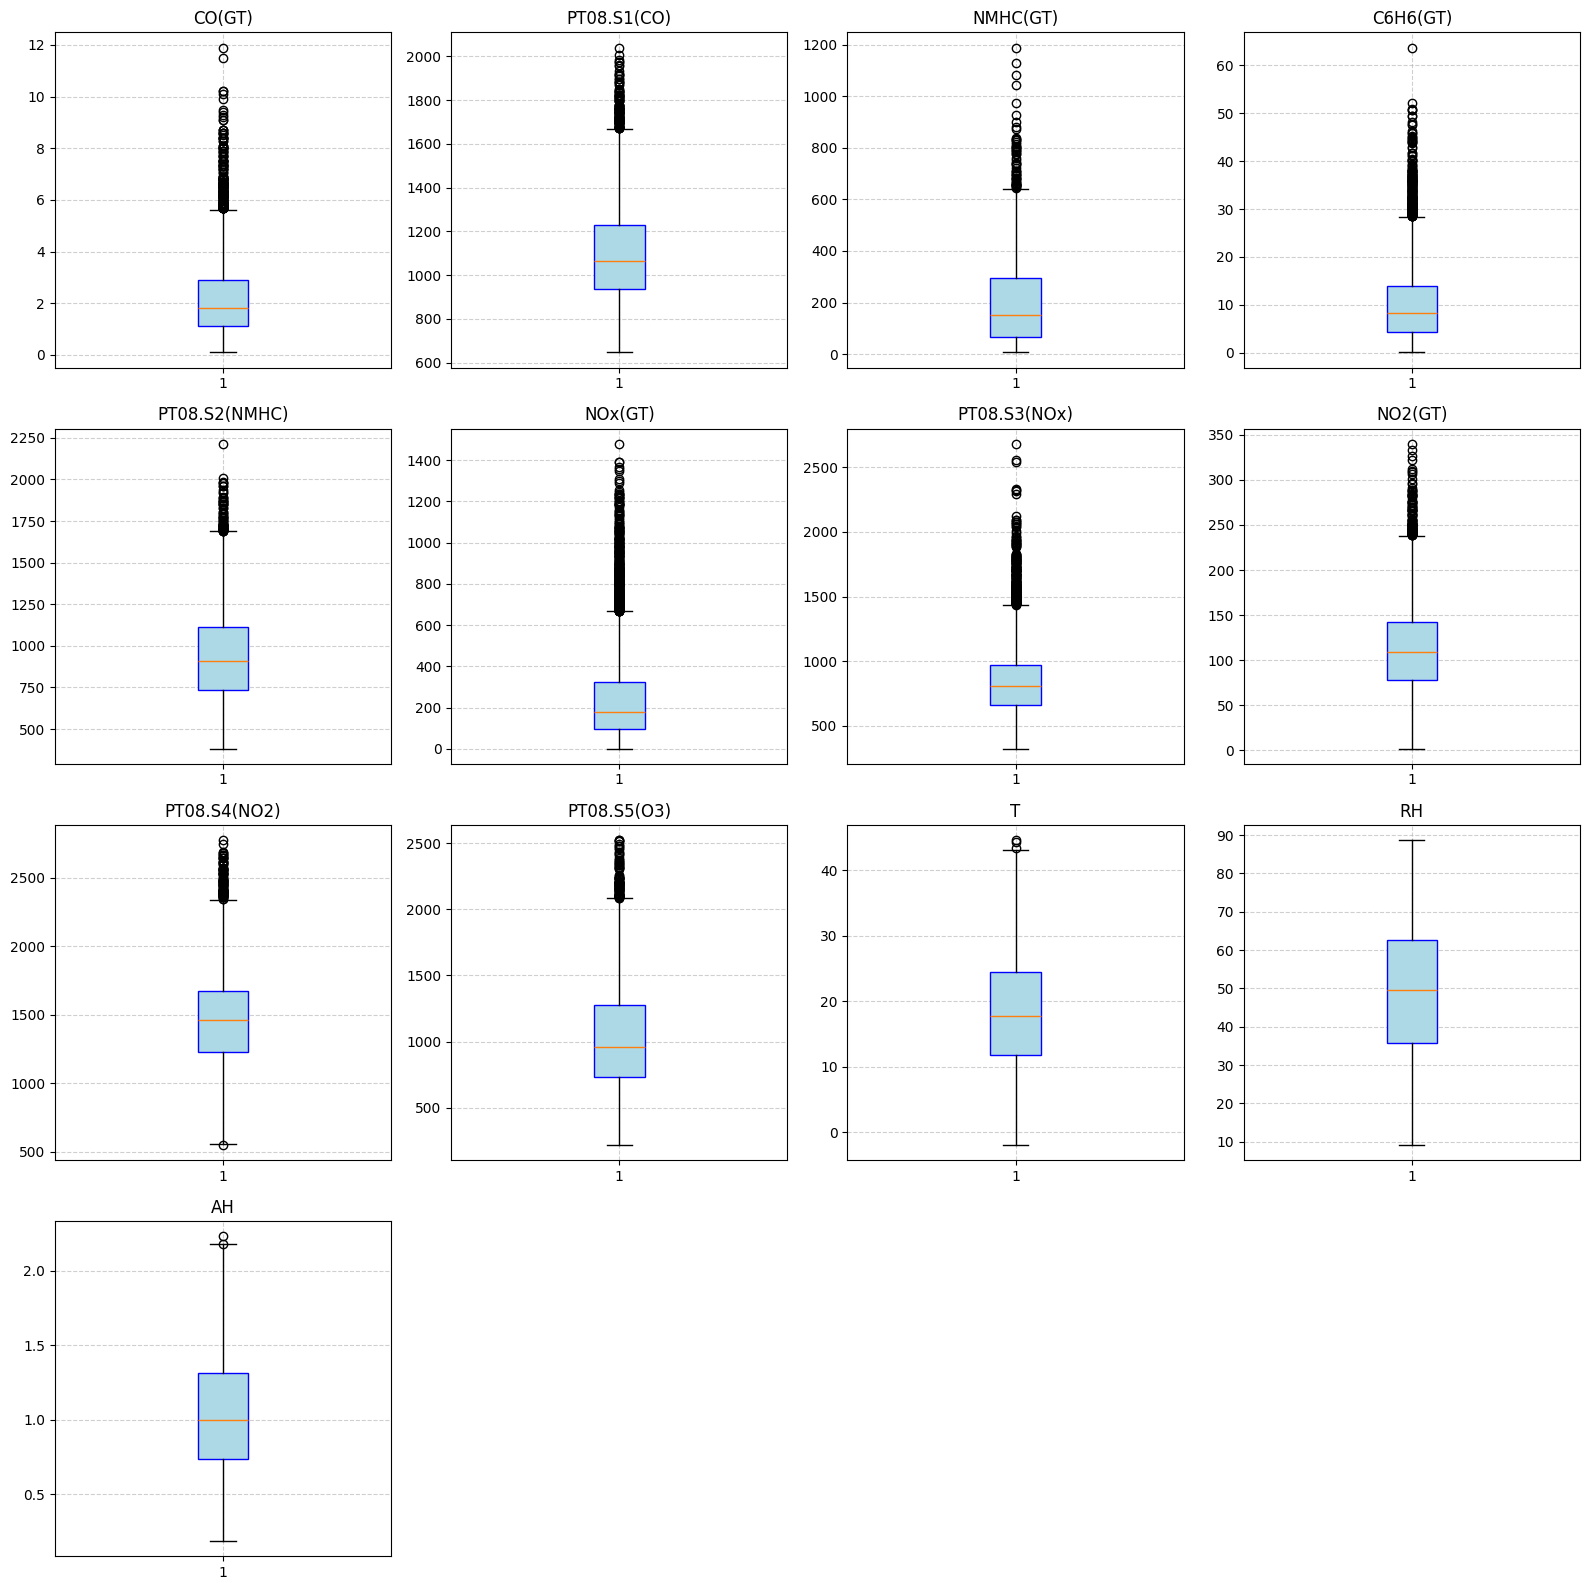

In [ ]:
import matplotlib.pyplot as plt
import math

# Выбираем только числовые столбцы (все каналы)
numeric_cols = df_clean.select_dtypes(include=['number']).columns
num_plots = len(numeric_cols)

# Считаем сетку для графиков (например, 4 строки на 4 колонки)
cols = 4
rows = math.ceil(num_plots / cols)

fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4))
axes = axes.flatten()  # Делаем одномерный массив из сетки

for i, col in enumerate(numeric_cols):
    # Строим boxplot для каждого канала отдельно, удаляя NaN для корректности
    axes[i].boxplot(df_clean[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightblue', color='blue'))
    axes[i].set_title(col, fontsize=12)
    axes[i].grid(True, linestyle='--', alpha=0.6)

# Прячем пустые графики в сетке, если они остались
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

/tmp/ipykernel_399/1775295901.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df_clean[col].dropna() for col in cols_to_plot], labels=cols_to_plot)


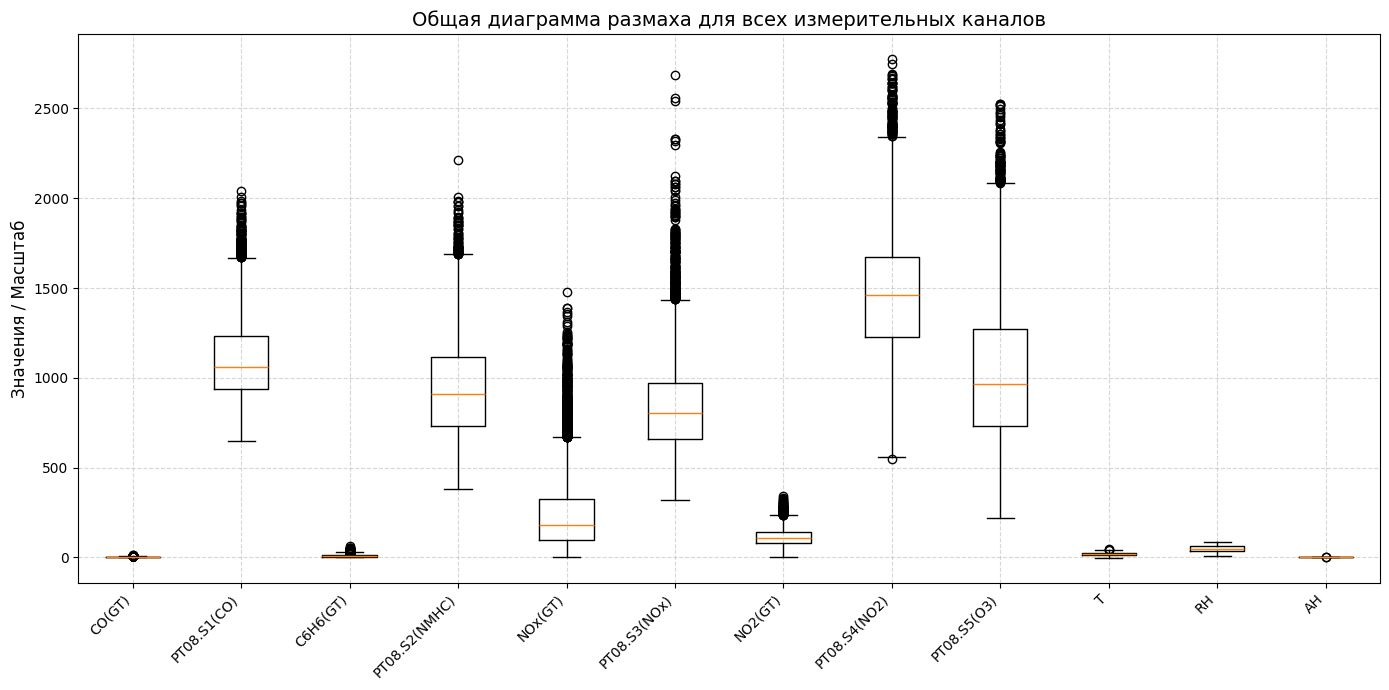

In [ ]:
# Выбираем все числовые столбцы, кроме полностью пустого NMHC(GT)
cols_to_plot = [col for col in df_clean.select_dtypes(include=['number']).columns if col != 'NMHC(GT)']

plt.figure(figsize=(14, 7))

# Строим общую диаграмму размаха
# dropna() здесь не сработает для всего df сразу, поэтому рисуем через seaborn или стандартный matplotlib, передавая списки данных без NaN
plt.boxplot([df_clean[col].dropna() for col in cols_to_plot], labels=cols_to_plot)

plt.title('Общая диаграмма размаха для всех измерительных каналов', fontsize=14)
plt.ylabel('Значения / Масштаб', fontsize=12)
plt.xticks(rotation=45, ha='right') # Поворачиваем названия каналов, чтобы они не слипались
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

                 CO(GT)  PT08.S1(CO)  NMHC(GT)  C6H6(GT)  PT08.S2(NMHC)  \
CO(GT)         1.000000     0.879288  0.889734  0.931078       0.915514   
PT08.S1(CO)    0.879288     1.000000  0.790670  0.883795       0.892964   
NMHC(GT)       0.889734     0.790670  1.000000  0.902559       0.877696   
C6H6(GT)       0.931078     0.883795  0.902559  1.000000       0.981950   
PT08.S2(NMHC)  0.915514     0.892964  0.877696  0.981950       1.000000   
NOx(GT)        0.795028     0.713654  0.812685  0.718839       0.704435   
PT08.S3(NOx)  -0.703446    -0.771938 -0.771135 -0.735744      -0.796703   
NO2(GT)        0.683343     0.641529  0.731193  0.614474       0.646245   
PT08.S4(NO2)   0.630703     0.682881  0.853267  0.765731       0.777254   
PT08.S5(O3)    0.854182     0.899324  0.766723  0.865689       0.880578   
T              0.022109     0.048627  0.391587  0.198956       0.241373   
RH             0.048890     0.114606 -0.191454 -0.061681      -0.090380   
AH             0.048556  

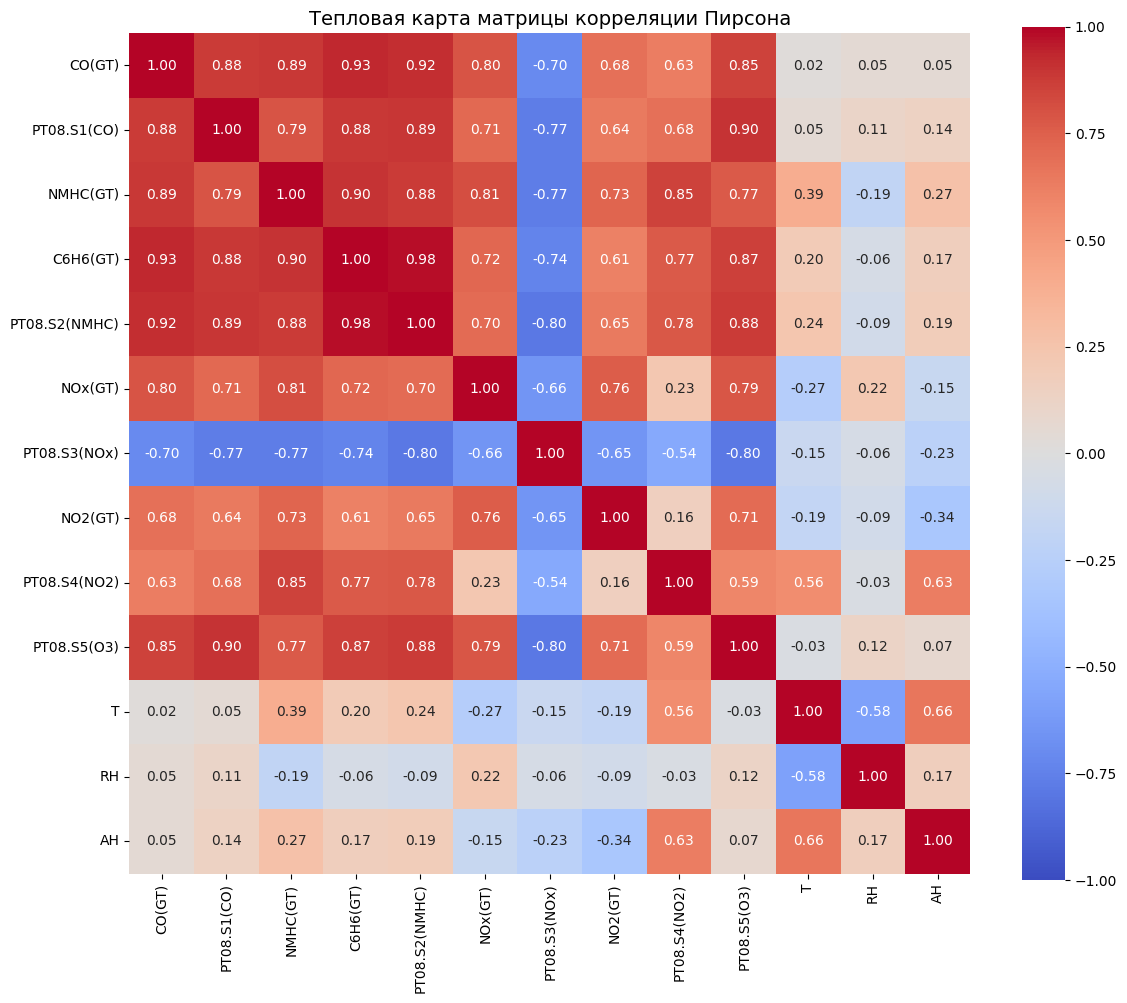

In [ ]:
import seaborn as sns
# 1. Вычисляем матрицу корреляции Пирсона для числовых столбцов
# (пропуски Pandas проигнорирует автоматически)
corr_matrix = df_clean.select_dtypes(include=['number']).corr(method='pearson')

# Отобразим саму матрицу в виде текста/таблицы
print(corr_matrix)

# 2. Визуализируем матрицу в виде тепловой карты
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, square=True)

plt.title('Тепловая карта матрицы корреляции Пирсона', fontsize=14)
plt.tight_layout()
plt.show()

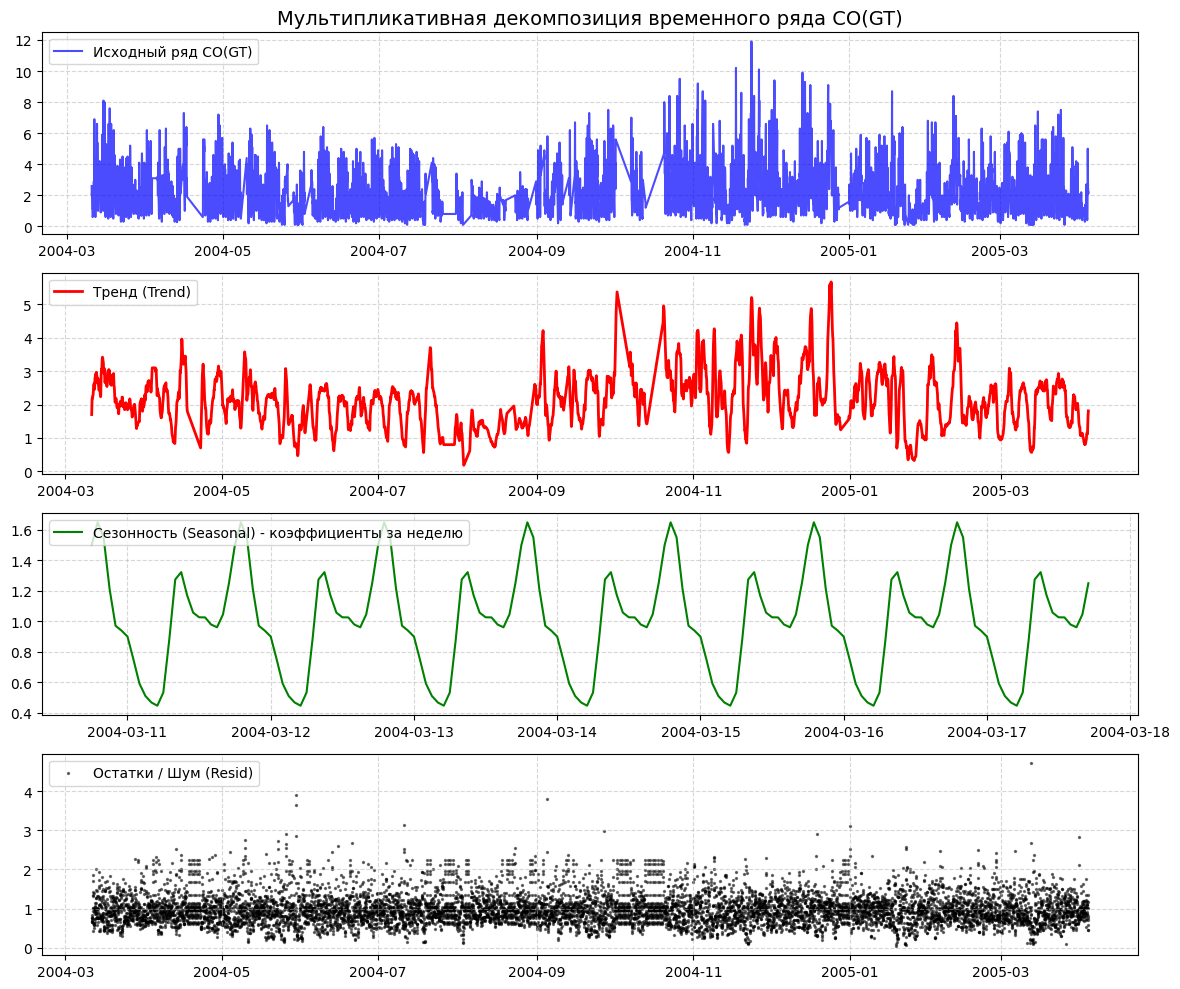

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. Готовим данные: берем канал CO(GT) и заполняем пропуски
co_series = df_clean['CO(GT)'].interpolate(method='linear')

# 2. Выполняем МУЛЬТИПЛИКАТИВНУЮ декомпозицию (model='multiplicative')
# period=24 означает суточную цикличесность (24 часа)
decomposition = seasonal_decompose(co_series, model='multiplicative', period=24)

# 3. Извлекаем составляющие
trend = decomposition.trend
seasonal = decomposition.seasonal
resid = decomposition.resid  # мультипликативный шум / остатки

# 4. Строим график всех составляющих
plt.figure(figsize=(12, 10))

# График 1: Исходный ряд
plt.subplot(4, 1, 1)
plt.plot(co_series, label='Исходный ряд CO(GT)', color='blue', alpha=0.7)
plt.title('Мультипликативная декомпозиция временного ряда CO(GT)', fontsize=14)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

# График 2: Тренд
plt.subplot(4, 1, 2)
plt.plot(trend, label='Тренд (Trend)', color='red', linewidth=2)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

# График 3: Сезонность
plt.subplot(4, 1, 3)
plt.plot(seasonal[:168], label='Сезонность (Seasonal) - коэффициенты за неделю', color='green')
# Показываем первые 7 дней (168 часов) для наглядности суточного ритма
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

# График 4: Остатки (Шум)
plt.subplot(4, 1, 4)
plt.scatter(resid.index, resid, label='Остатки / Шум (Resid)', color='black', s=2, alpha=0.5)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
# 1. Сначала избавимся от пропусков в CO (statsmodels не умеет работать с NaN)
# Мы заполняем пропуски предыдущими значениями (forward fill), так как это временной ряд
co_series = df['CO(GT)'].fillna(method='ffill')

# 2. Делаем декомпозицию ряда (период=24, так как данные часовые и цикл суточный)
decomposition = seasonal_decompose(co_series, model='additive', period=24)

# 3. Достаем компоненты
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

# Полезный сигнал — это сумма тренда и сезонности
# Удаляем NaN, которые автоматически образуются на краях при расчете тренда
signal = (trend + seasonal).dropna()
# Отрезаем шум под тот же размер, чтобы совпали строчки
noise = residual.loc[signal.index]

# 4. Считаем дисперсии (они по определению уже являются квадратом отклонения)
var_signal = np.var(signal)
var_noise = np.var(noise)

# 5. Считаем SNR по формуле через десятичный логарифм
snr = 10 * np.log10(var_signal / var_noise)

# 6. Красиво выводим результаты
print("="*40)
print(f"Дисперсия сигнала (Var_signal): {var_signal:.4f}")
print(f"Дисперсия шума (Var_noise):     {var_noise:.4f}")
print("-"*40)
print(f"Отношение в разы (Сигнал/Шум): {var_signal / var_noise:.2f} раз")
print(f"Итоговый SNR:                  {snr:.2f} dB")
print("="*40)

Дисперсия сигнала (Var_signal): 1.0252
Дисперсия шума (Var_noise):     1.0598
----------------------------------------
Отношение в разы (Сигнал/Шум): 0.97 раз
Итоговый SNR:                  -0.14 dB


/tmp/ipykernel_399/88782419.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  co_series = df['CO(GT)'].fillna(method='ffill')


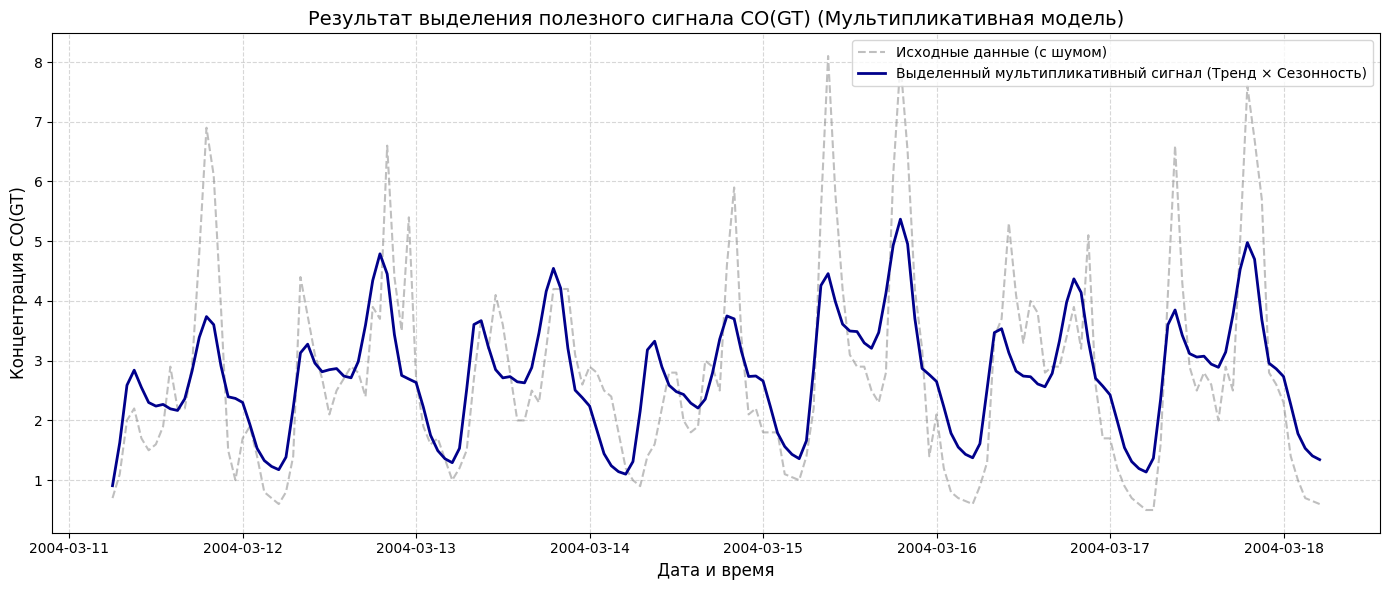

In [ ]:

from statsmodels.tsa.seasonal import seasonal_decompose

# 1. Готовим данные (как и раньше)
co_series = df_clean['CO(GT)'].interpolate(method='linear')

# 2. Выполняем МУЛЬТИПЛИКАТИВНУЮ декомпозицию (model='multiplicative')
decomposition = seasonal_decompose(co_series, model='multiplicative', period=24)

# 3. ВЫДЕЛЯЕМ СИГНАЛ (для мультипликативной модели: Тренд умножаем на Сезонность)
signal = (decomposition.trend * decomposition.seasonal).dropna()
co_series_trimmed = co_series.loc[signal.index]

# 4. Строим график сравнения за одну неделю
plt.figure(figsize=(14, 6))

plt.plot(co_series_trimmed.index[:168], co_series_trimmed[:168],
         label='Исходные данные (с шумом)', color='gray', alpha=0.5, linestyle='--')

plt.plot(signal.index[:168], signal[:168],
         label='Выделенный мультипликативный сигнал (Тренд × Сезонность)', color='darkblue', linewidth=2)

plt.title('Результат выделения полезного сигнала CO(GT) (Мультипликативная модель)', fontsize=14)
plt.xlabel('Дата и время', fontsize=12)
plt.ylabel('Концентрация CO(GT)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

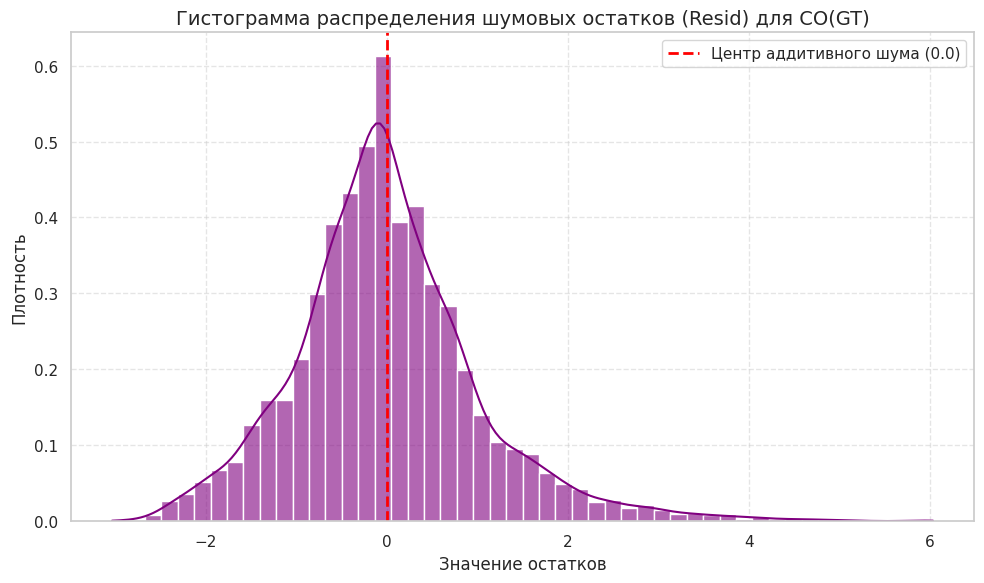

In [ ]:
# 1. Извлекаем остатки и удаляем NaN значения, которые образуются на краях ряда
noise = decomposition.resid.dropna()

# 2. Строим гистограмму распределения шума
plt.figure(figsize=(10, 6))

# Используем seaborn для построения гистограммы с линией ядерной оценки плотности (KDE)
sns.histplot(noise, kde=True, color='purple', bins=50, stat='density', alpha=0.6)

# ИСПРАВЛЕНО: Добавляем вертикальную линию на уровне 0.0 — центр для аддитивного шума
plt.axvline(x=0.0, color='red', linestyle='--', linewidth=2, label='Центр аддитивного шума (0.0)')

plt.title('Гистограмма распределения шумовых остатков (Resid) для CO(GT)', fontsize=14)
plt.xlabel('Значение остатков', fontsize=12)
plt.ylabel('Плотность', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()